# Forbes — Model-Agnostic Evaluation with Normalized MD Objective

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q opencv-python-headless scipy scikit-image easydict einops timm tqdm facenet-pytorch insightface onnxruntime-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 18.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 161.5 MB/s eta 0:00:00


In [ ]:
import os

ADAFACE_CKPT = '/content/drive/MyDrive/acv_project_weights/adaface_ir101_ms1mv2.ckpt'
MAGFACE_CKPT = '/content/drive/MyDrive/acv_project_weights/magface_epoch_00025.pth'
DATASET_ROOT = '/content/drive/MyDrive/acv_project_weights'
OUTPUT_DIR   = '/content/output'

N_REF         = 500   # pairs used to estimate normalization constants
N_EVAL        = 2500  # pairs used for evaluation

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Reference pairs : {N_REF}')
print(f'Evaluation pairs: {N_EVAL}')

Reference pairs : 500
Evaluation pairs: 2500


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import (
    Dropout, MaxPool2d, Sequential, Conv2d, Linear,
    BatchNorm1d, BatchNorm2d, PReLU, Sigmoid, Module
)
from scipy.optimize import fmin_l_bfgs_b
import torch.utils.data as data
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import namedtuple
from facenet_pytorch import InceptionResnetV1
from insightface.model_zoo import model_zoo

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition


## Backbone

In [ ]:
def initialize_weights(modules):
    for m in modules:
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None: m.bias.data.zero_()
        elif isinstance(m, nn.BatchNorm2d):
            m.weight.data.fill_(1); m.bias.data.zero_()
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None: m.bias.data.zero_()

class Flatten(Module):
    def forward(self, x): return x.view(x.size(0), -1)

class SEModule(Module):
    def __init__(self, channels, reduction):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1      = Conv2d(channels, channels // reduction, 1, bias=False)
        nn.init.xavier_uniform_(self.fc1.weight.data)
        self.relu     = nn.ReLU(inplace=True)
        self.fc2      = Conv2d(channels // reduction, channels, 1, bias=False)
        self.sigmoid  = Sigmoid()
    def forward(self, x):
        return x * self.sigmoid(self.fc2(self.relu(self.fc1(self.avg_pool(x)))))

class BasicBlockIR(Module):
    def __init__(self, in_channel, depth, stride):
        super().__init__()
        self.shortcut_layer = (
            MaxPool2d(1, stride) if in_channel == depth
            else Sequential(Conv2d(in_channel, depth, (1,1), stride, bias=False), BatchNorm2d(depth))
        )
        self.res_layer = Sequential(
            BatchNorm2d(in_channel),
            Conv2d(in_channel, depth, (3,3), (1,1), 1, bias=False),
            BatchNorm2d(depth), PReLU(depth),
            Conv2d(depth, depth, (3,3), stride, 1, bias=False),
            BatchNorm2d(depth)
        )
    def forward(self, x): return self.res_layer(x) + self.shortcut_layer(x)

class BasicBlockIRSE(BasicBlockIR):
    def __init__(self, in_channel, depth, stride):
        super().__init__(in_channel, depth, stride)
        self.res_layer.add_module('se_block', SEModule(depth, 16))

class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])): pass

def get_blocks(num_layers):
    def gb(ic, d, n, s=2):
        return [Bottleneck(ic, d, s)] + [Bottleneck(d, d, 1) for _ in range(n-1)]
    return [gb(64,64,3), gb(64,128,13), gb(128,256,30), gb(256,512,3)]

class Backbone(Module):
    def __init__(self, input_size, num_layers, mode='ir'):
        super().__init__()
        self.input_layer  = Sequential(Conv2d(3,64,(3,3),1,1,bias=False), BatchNorm2d(64), PReLU(64))
        unit              = BasicBlockIR if mode == 'ir' else BasicBlockIRSE
        s                 = 7*7 if input_size[0] == 112 else 14*14
        self.output_layer = Sequential(
            BatchNorm2d(512), Dropout(0.4), Flatten(),
            Linear(512*s, 512), BatchNorm1d(512, affine=False)
        )
        self.body = Sequential(*[unit(b.in_channel, b.depth, b.stride)
                                  for block in get_blocks(num_layers) for b in block])
        initialize_weights(self.modules())

    def forward(self, x):
        x = self.input_layer(x)
        for m in self.body: x = m(x)
        x = self.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm), norm

print('Backbone defined.')

Backbone defined.


## Four Feature Extractor Models

In [ ]:
class AdaFace(nn.Module):
    def __init__(self, ckpt_path):
        super().__init__()
        self.backbone = Backbone([112, 112], 100, 'ir')
        ckpt = torch.load(ckpt_path, map_location='cpu')
        sd   = {k[6:]: v for k, v in ckpt['state_dict'].items() if k.startswith('model.')}
        self.backbone.load_state_dict(sd)

    def forward(self, x):
        x = self.backbone.input_layer(x)
        for m in self.backbone.body: x = m(x)
        x    = self.backbone.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm), norm


class MagFace(nn.Module):
    def __init__(self, ckpt_path):
        super().__init__()
        self.backbone  = Backbone([112, 112], 100, 'ir')
        ckpt       = torch.load(ckpt_path, map_location='cpu')
        state_dict = ckpt.get('state_dict', ckpt)
        new_sd     = {}
        for k, v in state_dict.items():
            if k.startswith('features.'): new_sd[k[len('features.'):]] = v
            else: new_sd[k] = v
        self.backbone.load_state_dict(new_sd, strict=False)

    def forward(self, x):
        x = self.backbone.input_layer(x)
        for m in self.backbone.body: x = m(x)
        x    = self.backbone.output_layer(x)
        norm = torch.norm(x, 2, 1, True)
        return torch.div(x, norm), norm


class FaceNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = InceptionResnetV1(pretrained='vggface2').eval()

    def forward(self, x):
        x    = F.interpolate(x, size=(160, 160), mode='bilinear', align_corners=False)
        emb  = self.net(x)
        norm = torch.norm(emb, 2, 1, True)
        return torch.div(emb, norm), norm


class ArcFace(nn.Module):
    def __init__(self):
        super().__init__()
        from insightface.app import FaceAnalysis
        app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
        app.prepare(ctx_id=-1)
        model_path = os.path.expanduser('~/.insightface/models/buffalo_l/w600k_r50.onnx')
        self.onnx  = model_zoo.get_model(model_path,
                                          providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        self.onnx.prepare(ctx_id=0)

    def forward(self, x):
        imgs = ((x.detach().cpu().permute(0,2,3,1).numpy() + 1) * 127.5).astype(np.uint8)
        embeddings = []
        for img in imgs:
            emb = self.onnx.get_feat(img[:, :, ::-1].copy()).flatten()
            embeddings.append(torch.from_numpy(emb).float())
        emb  = torch.stack(embeddings).to(device)
        norm = torch.norm(emb, 2, 1, True)
        return torch.div(emb, norm), norm


print('All four models defined.')

All four models defined.


## Pattern Utilities

In [ ]:
def Mosaicking(x, alpha=None):
    b, c, h, w = x.size()
    y = torch.stack(torch.stack(x.chunk(7, dim=2)).chunk(7, dim=4)).mean(dim=(-1,-2)).permute(2,3,1,0)
    return F.interpolate(y, (h, w), mode='nearest')

def Horiz_mean(x, param=None):
    b, c, h, w = x.size()
    return torch.mean(x, dim=3, keepdim=True).expand(b, c, h, w)

def Vertic_mean(x, param=None):
    b, c, h, w = x.size()
    return torch.mean(x, dim=2, keepdim=True).expand(b, c, h, w)

def Warping(x, flo):
    B, C, H, W = x.size()
    _, _, h, w = flo.size()
    xx   = torch.arange(0, W).view(1,1,1,W).expand(B,1,H,W)
    yy   = torch.arange(0, H).view(1,1,H,1).expand(B,1,H,W)
    grid = torch.cat((xx, yy), 1).float()
    flo  = F.interpolate(flo, (H, W), mode='bilinear', align_corners=True)
    flo[:, 0] = flo[:, 0] * H / h
    flo[:, 1] = flo[:, 1] * W / w
    if x.is_cuda: grid = grid.to(x.device)
    vgrid = torch.autograd.Variable(grid) + flo
    vgrid[:, 0] = 2.0 * vgrid[:, 0] / max(W-1, 1) - 1.0
    vgrid[:, 1] = 2.0 * vgrid[:, 1] / max(H-1, 1) - 1.0
    return nn.functional.grid_sample(x, vgrid.permute(0,2,3,1), align_corners=True)

def Sinusoid(x, param=None):
    b, c, h, w = x.size()
    wp, hp, _, _, _, _ = param.size()
    wg, hg = w // wp, h // hp
    yy   = torch.linspace(-np.pi, np.pi, hg).view(1,1,1,1,1,hg,1).expand(wp,hp,1,3,1,hg,wg)
    xx   = torch.linspace(-np.pi, np.pi, wg).view(1,1,1,1,1,1,wg).expand(wp,hp,1,3,1,hg,wg)
    grid = torch.cat((xx, yy), 4).float().to(x.device)
    grid = grid[:,:,:,:,0] * param + grid[:,:,:,:,1] * (1 - param)
    return (0.2 * torch.sin(grid * 4)).permute(2,3,1,4,0,5).reshape(b,c,h,w)

def Checkerboard(x, param=None):
    b, c, h, w = x.size()
    param = torch.ones(7, 7, 1, 3, 1, 1).to(x.device)
    xx    = torch.arange(0, 4).view(1,1,1,4).expand(1,1,4,4)
    yy    = torch.arange(0, 4).view(1,1,4,1).expand(1,1,4,4)
    grid  = ((xx + yy) % 2).float() - 0.5
    grid  = F.interpolate(grid, (h//7, h//7), mode='nearest').to(x.device)
    return (param * grid).permute(2,3,1,4,0,5).reshape(1,c,h,w).expand(b,c,h,w) * 0.3

def Speckle(x, param=None):
    return F.interpolate(param, (x.size(2), x.size(3)), mode='bilinear')

def Scaling(x, input_color):
    b, c, h, w = x.size()
    bh = input_color.size()[1]
    bw = input_color.size()[0]
    x  = torch.stack(torch.stack(x.chunk(bh, dim=2)).chunk(bw, dim=4))
    x  = torch.clamp(((x + 1) * input_color / 2) * 2 - 1, min=-1, max=1)
    return x.permute(2,3,1,4,0,5).reshape(b,c,h,w)

def generate_zto(size, device):
    n = int(np.prod(size))
    return torch.rand(n, device=device).float(), [(0, 1)] * n

def generate_sym(size, device, value):
    n    = int(np.prod(size))
    prob = torch.rand(n, device=device).float()
    p    = torch.zeros(n, device=device).float()
    _min = 1.0 / value
    mask = prob > 0.5
    p[mask]  = torch.rand(int(mask.sum()), device=device) * (value - 1) + 1
    p[~mask] = torch.rand(int((~mask).sum()), device=device) * (1 - _min) + _min
    return p, [(_min, value)] * n

def generate_minmax(size, device, lo, hi):
    n = int(np.prod(size))
    return torch.rand(n, device=device).float() * (hi - lo) + lo, [(lo, hi)] * n

def generate_warp(size, device, lo, hi):
    n  = int(np.prod(size))
    p  = torch.rand(n, device=device).float() * (hi - lo) + lo
    pv = p.view(size)
    pv[:, :, [0, -1], :] = 0
    pv[:, :, :, [0, -1]] = 0
    p     = pv.view(-1)
    bound = [(lo, hi)] * n
    mask  = (p == 0).cpu().tolist()
    bound = [(0, 0) if m else b for m, b in zip(mask, bound)]
    return p, bound

def generate_blend(size, device):
    n = int(np.prod(size))
    return torch.rand(n, device=device).float(), [(None, None)] * n

def generate_param(transform, size, device):
    if transform == 'Warping':    return generate_warp(size, device, -0.3, 0.3)
    elif transform == 'Scaling':  return generate_sym(size, device, 1.1)
    elif transform == 'Sinusoid': return generate_zto(size, device)
    elif transform == 'Speckle':  return generate_minmax(size, device, -0.5, 0.5)
    elif 'blend' in transform:    return generate_blend(size, device)

print('Pattern utilities defined.')

Pattern utilities defined.


## Normalization Statistics

In [ ]:
class LFW(data.Dataset):
    def __init__(self, root, start=0, end=None):
        pairs       = np.load(os.path.join(root, 'lfw', 'lfw.npy'))
        issame      = np.load(os.path.join(root, 'lfw', 'lfw_list.npy'))
        end         = end or len(pairs)
        self.pairs  = pairs[start:end]
        self.issame = issame[start:end]

    def __getitem__(self, i):
        s = self.pairs[i]
        return {'im1': (s[0] + 1) / 2, 'im2': (s[1] + 1) / 2, 'tf': self.issame[i] * 1}

    def __len__(self):
        return len(self.pairs)


def compute_norm_stats(model, n_ref, batch_size=32):
    """
    Compute per-model normalization constants from the reference split.
    Returns (mu_same, mu_diff, std_same, std_diff).
    """
    loader = DataLoader(LFW(DATASET_ROOT, start=0, end=n_ref),
                        batch_size=batch_size, shuffle=False, num_workers=2)
    sims_same, sims_diff = [], []

    with torch.no_grad():
        for blob in loader:
            im1 = (blob['im1'] * 2 - 1).to(device)
            im2 = (blob['im2'] * 2 - 1).to(device)
            tf  = blob['tf']
            f1, _ = model(im1)
            f2, _ = model(im2)
            sim = torch.bmm(
                f1.unsqueeze(1), f2.unsqueeze(2)
            ).squeeze(1).squeeze(1).cpu()
            for s, label in zip(sim, tf):
                if label == 1: sims_same.append(s.item())
                else:          sims_diff.append(s.item())

    mu_same  = float(np.mean(sims_same))
    mu_diff  = float(np.mean(sims_diff))
    std_same = float(np.std(sims_same))
    std_diff = float(np.std(sims_diff))

    print(f'  mu_same={mu_same:.4f}  std_same={std_same:.4f}')
    print(f'  mu_diff={mu_diff:.4f}  std_diff={std_diff:.4f}')
    print(f'  Separation (mu_same - mu_diff): {mu_same - mu_diff:.4f}')

    return mu_same, mu_diff, std_same, std_diff


def cal_accuracy(y_score, y_true):
    y_score, y_true = np.asarray(y_score), np.asarray(y_true)
    best_acc, best_th = 0, 0
    for th in y_score:
        acc = np.mean(((y_score >= th) == y_true).astype(int))
        if acc > best_acc:
            best_acc, best_th = acc, th
    return best_acc, best_th


print('Dataset and normalization functions defined.')

Dataset and normalization functions defined.


## Normalized BRS Optimizer

In [ ]:
class BRSNormalized:
    def __init__(self, model, anchor_model, device, args, mu_same, mu_diff,
                 anchor_mu_same, anchor_mu_diff):
        self.model        = model
        self.anchor_model = anchor_model   # AdaFace as anchor
        self.device       = device
        self.args         = args
        self.mu_same      = mu_same
        self.mu_diff      = mu_diff
        self.scale        = mu_same - mu_diff
        self.anchor_scale = anchor_mu_same - anchor_mu_diff
        self.softmax  = torch.nn.Softmax(dim=0).to(device)
        self.upsample = torch.nn.Upsample(size=(112, 112), mode='nearest')
        self.energy_u_warp         = torch.nn.MarginRankingLoss(margin=args.transform_margin['Warping']).to(device)
        self.energy_u_random_noise = torch.nn.MarginRankingLoss(margin=args.transform_margin['Speckle']).to(device)
        self.energy_c1             = torch.nn.MarginRankingLoss(margin=args.transform_margin['Scaling']).to(device)
        self.energy_c2             = torch.nn.MarginRankingLoss(margin=-1/args.transform_margin['Scaling']).to(device)
        self.transform_size = {}

    def normalized_cos_loss(self, inp, tgt, scale, mu_diff):
        sim_raw = torch.bmm(
            inp.unsqueeze(1), tgt.unsqueeze(2)
        ).squeeze(1).squeeze(1) / (
            torch.linalg.norm(inp, dim=1) * torch.linalg.norm(tgt, dim=1) + 1e-8
        )
        sim_norm = (sim_raw - mu_diff) / (scale + 1e-8)
        return 20 * torch.sum(1 - sim_norm)

    def normalized_dist_loss(self, inp, tgt, scale):
        raw = torch.mean(torch.sqrt((inp - tgt) ** 2 + 1e-6), dim=1)
        return torch.sum(raw / (scale + 1e-8))

    def _size_init(self):
        b, c, h, w = self.in_img.size()
        _, ct, ht, wt = self.args.transform_size['Warping']
        self.transform_size['Warping'] = [b, ct, ht, wt]
        ht, wt, _, ct, _, _ = self.args.transform_size['Scaling']
        self.transform_size['Scaling'] = [ht, wt, b, ct, 1, 1]
        ht, wt, ct, _, _ = self.args.transform_size['Sinusoid']
        self.transform_size['Sinusoid'] = [ht, wt, b, ct, 1, 1]
        _, ct, ht, wt = self.args.transform_size['Speckle']
        self.transform_size['Speckle'] = [b, ct, ht, wt]
        _, _, ht, wt = self.args.transform_size['Averaging_blend']
        self.transform_size['Averaging_blend'] = [3, b, 3, ht, wt]
        self.transform_size['Noising_blend']   = [3, b, 3, ht, wt]

    def _apply_transforms(self, in_img, params_tensor, training=False):
        b, c, h, w = in_img.shape
        ob_img  = in_img.clone()
        ob_imgs = None
        loss_HI = 0.0
        for key in self.args.transform_type:
            try:
                _len  = int(np.prod(self.transform_size[key]))
                param, params_tensor = params_tensor.split([_len, len(params_tensor) - _len])
                param = param.view(self.transform_size[key])
                if key in ('Averaging_blend', 'Noising_blend'):
                    weights = self.upsample(
                        self.softmax(param).view(b*3, c,
                            self.transform_size[key][-2],
                            self.transform_size[key][-1])
                    ).view(3, b, c, h, w)
                    if key == 'Averaging_blend':
                        ob_img  = torch.sum(ob_imgs * weights, dim=0)
                        ob_imgs = None
                    else:
                        ob_img  = torch.sum(ob_imgs * weights, dim=0) + ob_img
                elif key == 'Warping':
                    ob_img = Warping(ob_img, param)
                    if training:
                        loss_HI += self.energy_u_warp(param, torch.zeros_like(param), param.sign())
                elif key == 'Scaling':
                    ob_img = Scaling(ob_img, param)
                    if training:
                        p1 = param[param >= 1]
                        p2 = param[param  < 1]
                        if p1.numel() > 0: loss_HI += self.energy_c1(p1, torch.zeros_like(p1), p1.sign())
                        if p2.numel() > 0: loss_HI += self.energy_c2(torch.zeros_like(p2), p2, p2.sign())
                else:
                    result  = eval(key)(ob_img, param)
                    if key == 'Speckle' and training:
                        loss_HI += self.energy_u_random_noise(param, torch.zeros_like(param), param.sign())
                    ob_imgs = result.unsqueeze(0) if ob_imgs is None else torch.cat((ob_imgs, result.unsqueeze(0)))
            except Exception:
                result  = eval(key)(ob_img, None)
                ob_imgs = result.unsqueeze(0) if ob_imgs is None else torch.cat((ob_imgs, result.unsqueeze(0)))
        return ob_img, loss_HI

    def optimize(self, in_img):
        self.in_img = in_img
        self._size_init()
        init_params, bounds = None, []
        for key in self.args.transform_type:
            try:
                kp, bound = generate_param(key, self.transform_size[key], in_img.device)
                bounds.extend(bound)
                init_params = kp if init_params is None else torch.cat((init_params, kp))
            except Exception: pass
        x0     = init_params.detach().cpu().numpy().ravel()
        result = fmin_l_bfgs_b(
            func=self._optimize_function, x0=x0,
            m=20, factr=0, pgtol=1e-8, maxfun=20, maxiter=40, bounds=bounds)
        op = torch.from_numpy(result[0]).float().to(self.device)
        optimized_img, _ = self._apply_transforms(in_img, op, training=False)
        return optimized_img

    def _optimize_function(self, in_params):
        in_img = self.in_img
        b      = in_img.shape[0]
        x      = torch.from_numpy(in_params).float().to(self.device)
        x.requires_grad_(True)

        with torch.enable_grad():
            ob_img,  loss_HI = self._apply_transforms(in_img, x, training=True)

            # Primary model loss
            feat_ob, _  = self.model(ob_img)
            feat_in, _  = self.model(in_img)
            loss_primary = (self.normalized_dist_loss(feat_ob, feat_in, self.scale) +
                            self.normalized_cos_loss(feat_ob, feat_in, self.scale, self.mu_diff))

            # Anchor model loss (AdaFace) — provides gradient directions
            # that generalize across embedding spaces
            anchor_mu_diff  = norm_stats['AdaFace'][1]
            anchor_scale    = norm_stats['AdaFace'][0] - norm_stats['AdaFace'][1]
            feat_ob_a, _ = self.anchor_model(ob_img)
            feat_in_a, _ = self.anchor_model(in_img)
            loss_anchor  = (self.normalized_dist_loss(feat_ob_a, feat_in_a, anchor_scale) +
                            self.normalized_cos_loss(feat_ob_a, feat_in_a, anchor_scale, anchor_mu_diff))

            # Equal weight sum — both models must agree on the gradient direction
            loss = loss_HI + 0.5 * loss_primary + 0.5 * loss_anchor

        f_val  = loss.detach().cpu().numpy()
        loss.backward()
        f_grad = x.grad.cpu().numpy().ravel().astype(float) * b
        return [f_val, f_grad]


print('Normalized BRS with anchor model defined.')

Normalized BRS with anchor model defined.


## Configuration

In [ ]:
import types

args = types.SimpleNamespace()
args.transform_type = [
    'Mosaicking', 'Horiz_mean', 'Vertic_mean', 'Averaging_blend',
    'Warping', 'Sinusoid', 'Checkerboard', 'Speckle', 'Noising_blend', 'Scaling'
]
args.transform_size = {
    'Warping':         [1, 2, 7, 7],
    'Scaling':         [7, 7, 1, 3, 1, 1],
    'Sinusoid':        [7, 7, 3, 1, 1],
    'Speckle':         [1, 3, 7, 7],
    'Averaging_blend': [3, 3, 7, 7],
    'Noising_blend':   [3, 3, 7, 7]
}
args.transform_margin = {'Warping': 0.05, 'Scaling': 1.05, 'Speckle': 0.1}
print('Configuration set.')

Configuration set.


## Load All Models

In [ ]:
adaface_model = AdaFace(ADAFACE_CKPT).to(device).eval()
print('AdaFace loaded.')

magface_model = MagFace(MAGFACE_CKPT).to(device).eval()
print('MagFace loaded.')

facenet_model = FaceNet().to(device).eval()
print('FaceNet loaded.')

arcface_model = ArcFace().eval()
print('ArcFace loaded.')

AdaFace loaded.
MagFace loaded.
FaceNet loaded.
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 1

## Compute Normalization Constants for Each Model

In [ ]:
norm_stats = {}

for name, model in [('AdaFace', adaface_model), ('MagFace', magface_model),
                    ('FaceNet', facenet_model), ('ArcFace', arcface_model)]:
    print(f'Computing stats for {name}...')
    norm_stats[name] = compute_norm_stats(model, N_REF)

print('\nNormalization constants computed for all models.')

Computing stats for AdaFace...
  mu_same=0.6683  std_same=0.1207
  mu_diff=0.0015  std_diff=0.0601
  Separation (mu_same - mu_diff): 0.6668
Computing stats for MagFace...
  mu_same=0.9332  std_same=0.0216
  mu_diff=0.9240  std_diff=0.0171
  Separation (mu_same - mu_diff): 0.0092
Computing stats for FaceNet...
  mu_same=0.7647  std_same=0.1029
  mu_diff=0.0220  std_diff=0.1560
  Separation (mu_same - mu_diff): 0.7427
Computing stats for ArcFace...
  mu_same=0.6763  std_same=0.1075
  mu_diff=0.0054  std_diff=0.0614
  Separation (mu_same - mu_diff): 0.6709

Normalization constants computed for all models.


## Run Evaluation with Normalized BRS

In [ ]:
BATCH_SIZE = 16


def run_eval_normalized(model_name, model):
    mu_same, mu_diff, _, _ = norm_stats[model_name]
    print(f'\nEvaluating {model_name} with anchor BRS ({N_EVAL} pairs)...')

    # AdaFace is always the anchor — skip adding it as its own anchor
    anchor = adaface_model

    optimizer = BRSNormalized(
        model=model,
        anchor_model=anchor,
        device=device,
        args=args,
        mu_same=mu_same,
        mu_diff=mu_diff,
        anchor_mu_same=norm_stats['AdaFace'][0],
        anchor_mu_diff=norm_stats['AdaFace'][1]
    )

    loader = DataLoader(
        LFW(DATASET_ROOT, start=N_REF, end=N_REF + N_EVAL),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=2
    )
    labels, sims = [], []

    with torch.no_grad():
        pbar = tqdm(loader, desc=model_name, unit='batch',
                    bar_format='{l_bar}{bar:25}{r_bar}')
        for blob in pbar:
            for k in ('im1', 'im2'):
                blob[k] = blob[k].to(device)
            b   = blob['im1'].shape[0]
            opt = optimizer.optimize(blob['im1'] * 2 - 1)
            feat, _ = model(torch.cat((opt, blob['im2'] * 2 - 1), dim=0))
            sim = torch.bmm(
                feat[:b].unsqueeze(1),
                feat[b:].unsqueeze(2)
            ).squeeze(1).squeeze(1)
            sims.extend(sim.cpu())
            labels.extend(blob['tf'])

    acc, th = cal_accuracy(sims, labels)
    print(f'  {model_name} — Accuracy: {acc:.4f} ({acc*100:.2f}%)  Threshold: {th:.4f}')
    return acc


results_normalized = {}
results_normalized['AdaFace'] = run_eval_normalized('AdaFace', adaface_model)
results_normalized['MagFace'] = run_eval_normalized('MagFace', magface_model)
results_normalized['FaceNet'] = run_eval_normalized('FaceNet', facenet_model)
results_normalized['ArcFace'] = run_eval_normalized('ArcFace', arcface_model)

print('\n')
print('=' * 45)
print('  RESULTS WITH ANCHOR BRS')
print('=' * 45)
for name, acc in results_normalized.items():
    print(f'  {name:<10}  {acc*100:.2f}%')
print('=' * 45)


Evaluating AdaFace with anchor BRS (2500 pairs)...


AdaFace: 100%|█████████████████████████| 157/157 [10:06<00:00,  3.86s/batch]


  AdaFace — Accuracy: 0.9812 (98.12%)  Threshold: 0.1159

Evaluating MagFace with anchor BRS (2500 pairs)...


MagFace: 100%|█████████████████████████| 157/157 [10:08<00:00,  3.88s/batch]


  MagFace — Accuracy: 0.6256 (62.56%)  Threshold: 0.9397

Evaluating FaceNet with anchor BRS (2500 pairs)...


FaceNet: 100%|█████████████████████████| 157/157 [08:28<00:00,  3.24s/batch]


  FaceNet — Accuracy: 0.9412 (94.12%)  Threshold: 0.2705

Evaluating ArcFace with anchor BRS (2500 pairs)...


ArcFace: 100%|█████████████████████████| 157/157 [10:31<00:00,  4.02s/batch]

  ArcFace — Accuracy: 0.7368 (73.68%)  Threshold: 0.0494


  RESULTS WITH ANCHOR BRS
  AdaFace     98.12%
  MagFace     62.56%
  FaceNet     94.12%
  ArcFace     73.68%


## Before vs After Comparison Plot

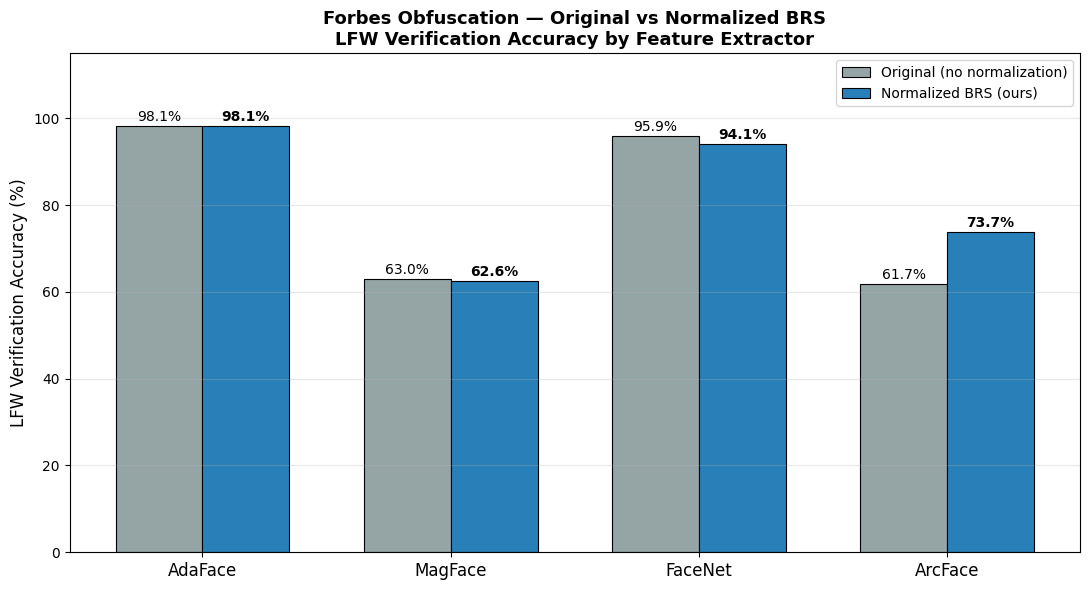

Saved: /content/output/normalized_comparison.png


In [ ]:
# Original results from the previous notebook (without normalization)
results_original = {
    'AdaFace': 0.9810,
    'MagFace': 0.6300,
    'FaceNet': 0.9590,
    'ArcFace': 0.6170
}

names  = list(results_normalized.keys())
before = [results_original[n] * 100 for n in names]
after  = [results_normalized[n] * 100 for n in names]

x      = np.arange(len(names))
width  = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, before, width, label='Original (no normalization)',
               color='#95a5a6', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, after,  width, label='Normalized BRS (ours)',
               color='#2980b9', edgecolor='black', linewidth=0.8)

for bar, val in zip(bars1, before):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

for bar, val in zip(bars2, after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 115)
ax.set_ylabel('LFW Verification Accuracy (%)', fontsize=12)
ax.set_title('Forbes Obfuscation — Original vs Normalized BRS\nLFW Verification Accuracy by Feature Extractor',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'normalized_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {save_path}')